In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


## EDA

In [6]:
df.shape

(1338, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


<Axes: xlabel='sex', ylabel='count'>

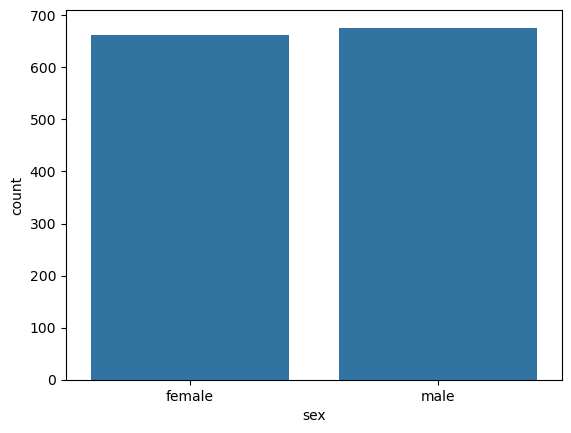

In [14]:
sns.countplot(data=df,x="sex")

<Axes: xlabel='region', ylabel='count'>

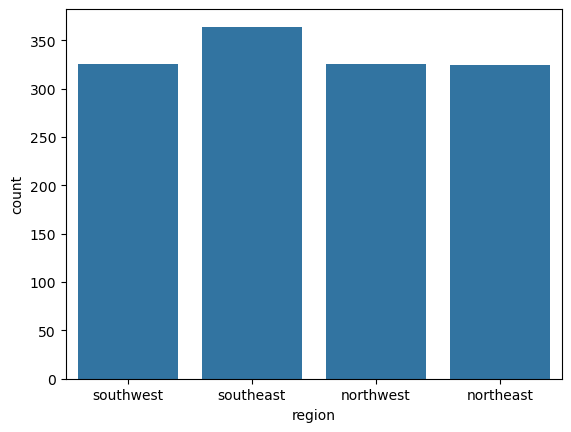

In [15]:
sns.countplot(data=df,x="region")

<Axes: xlabel='bmi', ylabel='Count'>

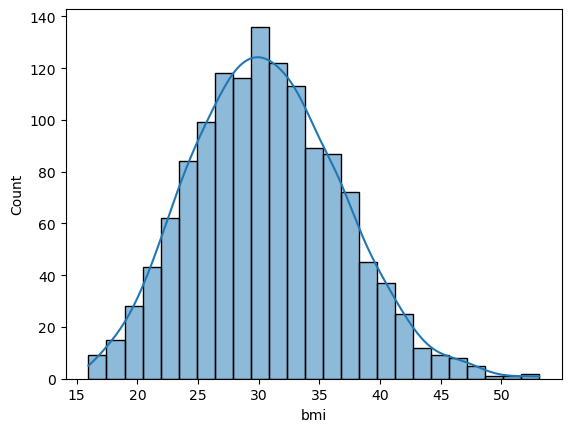

In [18]:
sns.histplot(data=df,x="bmi",kde=True)

<Axes: xlabel='charges', ylabel='Count'>

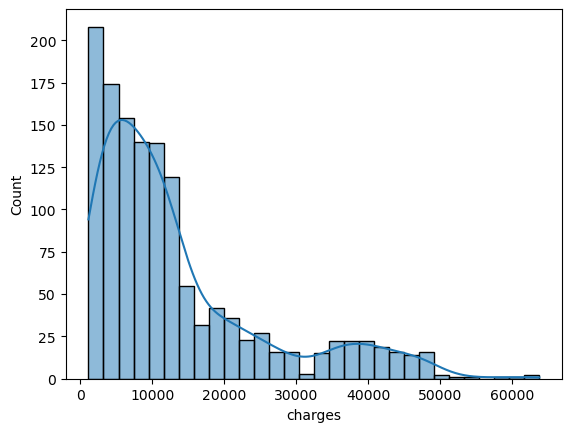

In [19]:
sns.histplot(data=df,x="charges",kde=True)

<Axes: xlabel='smoker', ylabel='charges'>

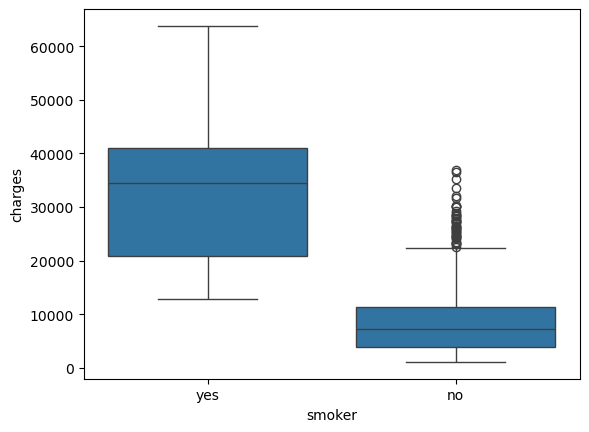

In [20]:
sns.boxplot(data=df,x="smoker",y="charges")

<Axes: xlabel='region', ylabel='charges'>

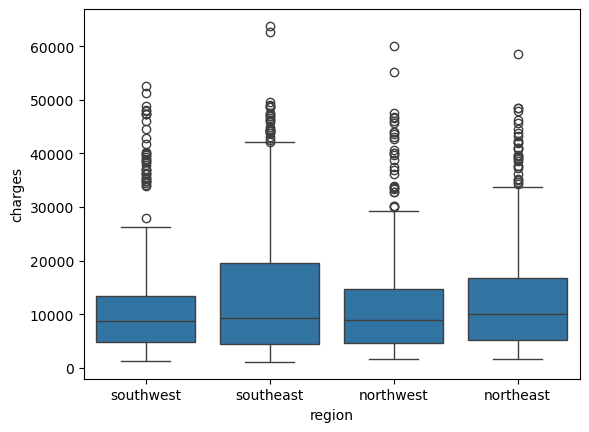

In [22]:
sns.boxplot(data=df,x="region",y="charges")

<Axes: xlabel='sex', ylabel='charges'>

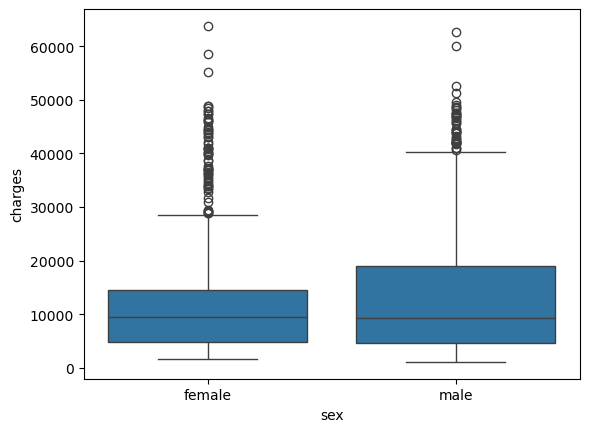

In [23]:
sns.boxplot(data=df,x="sex",y="charges")

<Axes: >

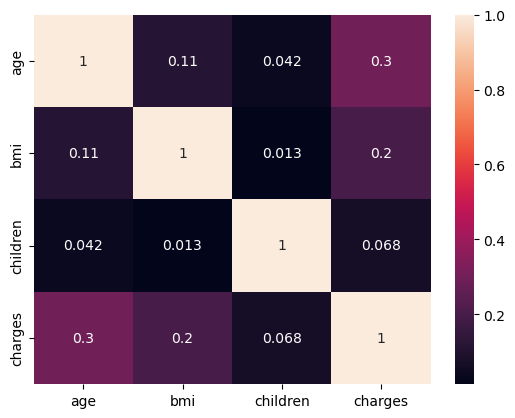

In [24]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Cleaning

In [25]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(1)

In [27]:
df = df.drop_duplicates()

In [28]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
x = df.drop("charges",axis=1)

In [31]:
y = df[["charges"]]

In [33]:
x

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest
1334,18,female,31.920,0,no,northeast
1335,18,female,36.850,0,no,southeast
1336,21,female,25.800,0,no,southwest


In [34]:
y

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
...,...
1333,10600.54830
1334,2205.98080
1335,1629.83350
1336,2007.94500


In [ ]:
## 

In [40]:
X = pd.get_dummies(x,drop_first=True)

In [41]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,False,True,False,False,True
1,18,33.770,1,True,False,False,True,False
2,28,33.000,3,True,False,False,True,False
3,33,22.705,0,True,False,True,False,False
4,32,28.880,0,True,False,True,False,False
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,True,False,True,False,False
1334,18,31.920,0,False,False,False,False,False
1335,18,36.850,0,False,False,False,True,False
1336,21,25.800,0,False,False,False,False,True


In [42]:
from sklearn.model_selection import train_test_split

In [43]:
 X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

In [44]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1069, 8)
(268, 8)
(1069, 1)
(268, 1)


## Build A Model

In [45]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

## Train A Model

In [46]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
x.columns

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')

In [52]:
model.coef_

array([[  248.21072022,   318.70144095,   533.0099888 ,  -101.54205399,
        23077.76459287,  -391.76145478,  -838.91961573,  -659.13975155]])

In [53]:
model.intercept_

array([-11092.65229595])

In [54]:
y_pred = model.predict(X_test)

In [55]:
y_pred

array([[ 8.14369388e+03],
       [ 5.73711568e+03],
       [ 1.43693149e+04],
       [ 3.17455136e+04],
       [ 8.96238666e+03],
       [ 1.31497224e+04],
       [ 3.04467607e+04],
       [ 1.45328881e+03],
       [ 1.06330184e+04],
       [ 1.13189438e+04],
       [ 1.03778536e+04],
       [ 3.31184377e+04],
       [ 3.10772527e+04],
       [ 1.74119253e+04],
       [ 1.08016743e+04],
       [ 9.52889964e+03],
       [ 4.16103784e+03],
       [ 3.17315373e+04],
       [ 3.21938875e+03],
       [ 5.22992460e+03],
       [ 3.54979004e+03],
       [ 3.02837740e+04],
       [ 1.48989509e+04],
       [ 3.04569093e+04],
       [ 3.11077668e+04],
       [ 5.51196081e+03],
       [ 3.55030401e+04],
       [ 3.65704810e+04],
       [ 1.14123133e+04],
       [ 1.42056990e+04],
       [ 6.50234029e+03],
       [ 1.27246945e+04],
       [ 3.99806590e+02],
       [ 1.20883980e+04],
       [ 3.96592069e+04],
       [ 1.23395540e+04],
       [ 4.74412279e+03],
       [ 3.91903157e+03],
       [ 3.0

In [57]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)
print(x.columns)
print(model.coef_)
print(model.intercept_)
y_pred = model.predict(X_test)
print(y_pred)

Index(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest',
       'region_southeast', 'region_southwest'],
      dtype='object')
[[  248.21072022   318.70144095   533.0099888   -101.54205399
  23077.76459287  -391.76145478  -838.91961573  -659.13975155]]
[-11092.65229595]
[[ 8.14369388e+03]
 [ 5.73711568e+03]
 [ 1.43693149e+04]
 [ 3.17455136e+04]
 [ 8.96238666e+03]
 [ 1.31497224e+04]
 [ 3.04467607e+04]
 [ 1.45328881e+03]
 [ 1.06330184e+04]
 [ 1.13189438e+04]
 [ 1.03778536e+04]
 [ 3.31184377e+04]
 [ 3.10772527e+04]
 [ 1.74119253e+04]
 [ 1.08016743e+04]
 [ 9.52889964e+03]
 [ 4.16103784e+03]
 [ 3.17315373e+04]
 [ 3.21938875e+03]
 [ 5.22992460e+03]
 [ 3.54979004e+03]
 [ 3.02837740e+04]
 [ 1.48989509e+04]
 [ 3.04569093e+04]
 [ 3.11077668e+04]
 [ 5.51196081e+03]
 [ 3.55030401e+04]
 [ 3.65704810e+04]
 [ 1.14123133e+04]
 [ 1.42056990e+04]
 [ 6.50234029e+03]
 [ 1.27246945e+04]
 [ 3.99806590e+02]
 [ 1.20883980e+04]
 [ 3.96592069e+04]
 [ 1.23395540e+04]
 [ 4.74412279e+03]
 [ 3

In [58]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))

4177.045561036319
35478020.67523559
0.8069287081198012
